# Energy-Dispersive X-Ray Spectrometry Data Processing 

This notebook details the analysis of all the metallic oxide unknowns characterized as apart of the *in situ* sedimentary hematite U-Pb approach. 



In [1]:
import numpy as np
import os,sys
import pandas as pd 
import matplotlib.pyplot as plt
from matplotlib.widgets import RectangleSelector
from mpl_interactions import ioff, panhandler, zoom_factory
from matplotlib import colors
from matplotlib import cm
import seaborn as sns
from scipy.stats import norm, sem
from scipy.stats import gaussian_kde
from scipy.stats import ks_2samp
import periodictable as pt
import matplotlib.patches as mpatches
import ternary
import mpltern
import re

plt.rcParams['pdf.fonttype']=42
plt.rcParams['font.family']='Arial'
plt.rcParams['font.size'] = 12

%matplotlib inline

## Functions 

#### Data Reading Function 

In [2]:
def read_pts(filepath):
    data = pd.read_csv(filepath, delimiter=',', header=None)
    tables = []
    current_table = []
    for row in data.values:
        if all(pd.isnull(row)):  # Check for a blank line
            if current_table:
                tables.append(pd.DataFrame(current_table))
                current_table = []
        else:
            current_table.append(row)


    if current_table:
        tables.append(pd.DataFrame(current_table))

    for df in tables:
        df.columns = df.iloc[1]  
        df['Grain']=df.iloc[0,0]
        move_col=df.pop('Grain')
        df.insert(0,'Grain',move_col)
        df.reset_index(drop=True, inplace=True)
        df.drop([0, 1],inplace=True)
 
    return tables

#### Monte Carlo Error Propagation

In [3]:
def mc_pts(tbls, iter_count=3000):
    """
    Monte Carlo simulation for atomic proportions with dynamic element detection.
    
    Parameters:
    - tbls: List of DataFrames (from read_pts)
    - iter_count: Number of MC iterations per grain
    
    Returns:
    - List of DataFrames with simulated atomic percentages
    """
    atm_table = []

    for i, tbl in enumerate(tbls):
        try:
            # 1. extract Grain ID (stored in the first column header or managed via read_pts)
            # Based on your read_pts, 'Grain' is a column. We take the first value.
            grain_id = tbl['Grain'].iloc[0]

            # 2. Identify elements present in this specific grain
            # We filter out rows that might not be element data if necessary, 
            # but usually 'Element' column holds the symbols.
            if 'Element' not in tbl.columns:
                print(f"Skipping table {i}: 'Element' column missing.")
                continue
            
            # Extract valid rows (ensure Element name is a string and not NaN)
            valid_rows = tbl[tbl['Element'].notna()]
            
            # Pre-fetch simulation parameters to avoid dataframe lookups inside the loop
            # Structure: { 'Fe': {'mean': 50.0, 'sigma': 0.5, 'mass': 55.845}, ... }
            sim_params = {}
            
            for _, row in valid_rows.iterrows():
                elem_sym = str(row['Element']).strip()
                
                # specific clean up for standard periodic table symbols if needed
                # e.g. sometimes data has 'Fe2O3', assuming simple elemental symbols here based on previous code
                
                try:
                    # Get Mean and Sigma
                    wt_mean = float(row['Wt%'])
                    wt_sigma = float(row['Wt% Sigma'])
                    
                    # Get Atomic Mass dynamically
                    # Handle 'O' explicitly if needed, otherwise standard lookup
                    if elem_sym == 'O': 
                        mass = pt.O.mass 
                    else:
                        mass = pt.elements.symbol(elem_sym).mass
                    
                    sim_params[elem_sym] = {
                        'mean': wt_mean,
                        'sigma': wt_sigma,
                        'mass': mass
                    }
                    
                except Exception as e:
                    # Logic to handle non-element rows or lookup failures
                    # print(f"Skipping row for {elem_sym} in grain {grain_id}: {e}")
                    continue

            if not sim_params:
                print(f"No valid elements found for grain {grain_id}")
                continue

            # 3. Monte Carlo Loop
            # We will store results in a dictionary of lists: {'Fe': [], 'Ti': [], ...}
            sim_results = {elem: [] for elem in sim_params.keys()}

            for _ in range(iter_count):
                current_iter_moles = {}
                total_moles = 0.0
                
                # A. Generate Random Weights & Convert to Moles
                for elem, params in sim_params.items():
                    # Sample from normal distribution
                    rand_wt = np.random.normal(params['mean'], params['sigma'])
                    
                    # Physical constraint: Wt% cannot be negative
                    rand_wt = max(rand_wt, 0.0)
                    
                    # Convert to moles (Atomic Proportion)
                    moles = rand_wt / params['mass']
                    
                    current_iter_moles[elem] = moles
                    total_moles += moles
                
                # B. Normalize to Atomic % (Fraction) and Store
                if total_moles > 0:
                    for elem in sim_results:
                        # Store as fraction (0-1) or Percent (0-100) depending on preference.
                        # Previous code appeared to return fractions (sum=1). 
                        sim_results[elem].append(current_iter_moles[elem] / total_moles)
                else:
                    for elem in sim_results:
                        sim_results[elem].append(0.0)

            # 4. Construct Output DataFrame
            atm_vals = pd.DataFrame(sim_results)
            
            # Re-insert Grain ID
            atm_vals.insert(0, 'Grain', grain_id)
            
            atm_table.append(atm_vals)

        except Exception as e:
            print(f"Error processing table {i}: {e}")
            continue

    return atm_table

#### Statistical Grouping

In [4]:
def pt_stats(tbls):
    """
    Aggregates Monte Carlo simulation results into a summary table.
    Dynamically handles any elements present in the input DataFrames.
    
    Parameters:
    - tbls: List of DataFrames (output from mc_pts)
    
    Returns:
    - DataFrame with Mean and Standard Error (SE) for every element found.
    """
    summary_data = []

    for tbl in tbls:
        # 1. Extract Grain ID
        grain_id = tbl['Grain'].iloc[0]
        
        # 2. Identify Element Columns (All columns except 'Grain')
        element_cols = [c for c in tbl.columns if c != 'Grain']
        
        # Initialize the dictionary for this grain
        grain_stats = {'Grain': grain_id}
        
        # 3. Calculate Statistics for each element
        for col in element_cols:
            try:
                # Calculate Mean
                mean_val = np.mean(tbl[col])
                
                # Calculate Standard Error of the Mean (SEM)
                # nan_policy='omit' is safer if simulations produced any NaNs
                se_val = sem(tbl[col], nan_policy='omit') 
                
                # Add to dictionary
                grain_stats[col] = mean_val
                grain_stats[f"{col}_se"] = se_val
                
            except Exception as e:
                print(f"Error calculating stats for {col} in grain {grain_id}: {e}")
                continue

        summary_data.append(grain_stats)

    # 4. Create Master DataFrame
    # Pandas will automatically align keys; grains missing specific elements will get NaN
    grain_table = pd.DataFrame(summary_data)

    # 5. Reorder Columns
    # Ensure 'Grain' is first, then sort the rest alphabetically.
    # This naturally groups 'Fe' next to 'Fe_se'
    cols = list(grain_table.columns)
    cols.remove('Grain')
    sorted_cols = ['Grain'] + sorted(cols)
    
    grain_table = grain_table[sorted_cols]

    return grain_table

#### Handle Map data

In [5]:
def read_maps(file_path):
    """
    Reads and aggregates map CSV files.
    Dynamically renames columns from 'element_mean'/'element_se' format
    to 'Element'/'Element_se' format to match point analysis stats.
    """
    arrs = []
    
    # List and sort CSV files
    csv_files = [os.path.join(file_path, f) for f in os.listdir(file_path) if f.endswith('.csv')]
    csv_files.sort()
    
    for full_path in csv_files:
        print("Reading array from: ", full_path)
        
        try:
            arr = pd.read_csv(full_path, delimiter=',', header=0)
            
            # extract filename for Grain ID generation
            filename = os.path.basename(full_path)
            
            # Generate Grain ID (Matches your previous logic: last 8 chars before extension)
            # Note: Ensure your filenames strictly follow the length convention, e.g., '...Grain01.csv'
            arr['Grain'] = 'BRc_' + filename[-12:-4]
            
            # --- Dynamic Renaming Logic ---
            rename_dict = {}
            for col in arr.columns:
                col_lower = col.lower()
                
                if col_lower.endswith('_mean'):
                    # e.g., 'fe_mean' -> 'Fe'
                    element = col[:-5].capitalize() # strip '_mean'
                    rename_dict[col] = element
                    
                elif col_lower.endswith('_se'):
                    # e.g., 'fe_se' -> 'Fe_se'
                    element = col[:-3].capitalize() # strip '_se'
                    rename_dict[col] = f"{element}_se"
            
            arr.rename(columns=rename_dict, inplace=True)
            # ------------------------------

            # Move 'Grain' to the first position
            if 'Grain' in arr.columns:
                move_col = arr.pop('Grain')
                arr.insert(0, 'Grain', move_col)
            
            arrs.append(arr)
            
        except Exception as e:
            print(f"Error processing file {filename}: {e}")
            continue

    if arrs:
        dfs = pd.concat(arrs, ignore_index=True)
        return dfs
    else:
        print("No valid files found or processed.")
        return pd.DataFrame()

#### Phase Splitting

In [6]:

def split_standards(df, std_patterns, unknown_regex=r'^(LR|BR)'):
    """
    Splits a master statistics DataFrame into an 'unknowns' DataFrame and 
    a 'standards' dictionary based on Grain ID patterns.

    Parameters:
    - df: The master DataFrame (from pt_stats).
    - std_patterns: Dictionary mapping standard names to regex patterns.
                    e.g. {'hematite': 'Hematite', ...}
    - unknown_regex: Regex string for unknown samples.

    Returns:
    - unknowns_df: DataFrame containing only the unknowns.
    - standards_map: Dictionary of DataFrames { 'hematite': [df], ... }
                     (Note: Returns list of 1 DF to match plotter expectation)
    """
    
    # 1. Extract Unknowns
    is_unknown = df['Grain'].str.contains(unknown_regex, regex=True, na=False)
    unknowns_df = df[is_unknown].copy()

    # 2. Extract Standards
    standards_map = {}
    
    for key, pattern in std_patterns.items():
        # Create mask for this standard
        mask = df['Grain'].str.contains(pattern, case=False, regex=True, na=False)
        
        # Filter data
        subset = df[mask].copy()
        
        # Store as a list of one DF (so it fits your existing plotter logic)
        standards_map[key] = [subset]

    return unknowns_df, standards_map

In [7]:
def classify_phases(df, rules):
    """
    Filters a DataFrame into mineral phases based on a dictionary of chemical constraints.
    Treats missing columns or NaNs as 0.0.
    
    Parameters:
    - df: The input DataFrame.
    - rules: A dictionary defining the phases. Format:
        {
            'PhaseName': {'Element': [min, max], ...},
            ...
        }
        
    Returns:
    - A dictionary of DataFrames: {'PhaseName': subset_df, ..., 'misc': remaining_df}
    """
    classified_tables = {}
    matched_indices = pd.Index([])

    for phase, constraints in rules.items():
        # Start with a mask of all True
        mask = pd.Series(True, index=df.index)
        
        for element, valid_range in constraints.items():
            min_val, max_val = valid_range
            
            # 1. Get the values to compare
            if element in df.columns:
                # If column exists, fill any specific row NaNs with 0
                current_values = df[element].fillna(0.0)
            else:
                # If column is missing entirely, treat as 0.0
                current_values = 0.0
            
            # 2. Update mask
            # If current_values is a scalar 0.0, pandas broadcasts it correctly against the Series
            mask = mask & (current_values >= min_val) & (current_values <= max_val)
        
        # Apply mask
        subset = df[mask].copy()
        subset['Phase_Class'] = phase
        classified_tables[phase] = subset
        
        matched_indices = matched_indices.union(subset.index)

    # Misc table
    misc_mask = ~df.index.isin(matched_indices)
    classified_tables['misc'] = df[misc_mask].copy()
    classified_tables['misc']['Phase_Class'] = 'misc'

    return classified_tables

#### Plotting Functions

In [8]:
def plot_feti_ternary(
    ax=None,
    # Explicit Unknowns Data
    hem_unk=None, 
    mag_unk=None, 
    ti_hem_unk=None, 
    ilm_unk=None, 
    gth_unk=None,   # <--- ADDED ARGUMENT
    misc_unk=None,
    # Standards Data (Dictionary)
    standards=None,
    # Style Dictionaries
    std_styles=None,
    unk_styles=None,
    # Config
    zoom=True
):
    
    if ax is None:
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(projection='ternary')

    def clean_data(df):
        df = df.copy()
        for col in ['O', 'Fe', 'Ti']:
            if col not in df.columns:
                df[col] = 0.0
        return df.fillna(0.0)

    # --- 1. Plot Standards ---
    if standards and std_styles:
        style_lookup = {k.lower(): v for k, v in std_styles.items()}
        
        for phase_name, data_list in standards.items():
            if not data_list: continue
            
            user_style = style_lookup.get(phase_name.lower())
            if not user_style: continue

            std_df = pd.concat(data_list)
            std_df = clean_data(std_df)
            
            plot_kwargs = user_style.copy()
            if 'label' not in plot_kwargs:
                plot_kwargs['label'] = f"{phase_name.capitalize()} Std"

            ax.scatter(std_df['O'], std_df['Fe'], std_df['Ti'], **plot_kwargs)

    # --- 2. Plot Unknowns ---
    # Added 'goethite' to this map
    unknowns_map = {
        'hematite': hem_unk,
        'magnetite': mag_unk,
        'titanohematite': ti_hem_unk,
        'ilmenite': ilm_unk,
        'goethite': gth_unk,  # <--- NEW MAPPING
        'misc': misc_unk
    }
    
    if unk_styles:
        for phase_key, df in unknowns_map.items():
            if df is not None and not df.empty:
                df = clean_data(df)
                
                # Get style or default
                user_style = unk_styles.get(phase_key, {'color': 'gray', 's': 10})
                
                plot_kwargs = user_style.copy()
                if 'label' not in plot_kwargs:
                    plot_kwargs['label'] = phase_key.capitalize()
                    
                ax.scatter(df['O'], df['Fe'], df['Ti'], **plot_kwargs)

    # --- 3. Formatting & Ticks ---
    ax.set_tlabel('O', fontsize=18)
    ax.set_llabel('Fe', fontsize=18)
    ax.set_rlabel('Ti', fontsize=18)
    
    ax.taxis.set_label_rotation_mode('horizontal')
    ax.laxis.set_label_rotation_mode('horizontal')
    ax.raxis.set_label_rotation_mode('horizontal')
    ax.grid()
    ax.set_axisbelow(True)

    if zoom:
        # Relaxed limits to catch edge points
        ax.set_ternary_max(1.0, 0.45, 0.45) 
        ax.set_ternary_min(0.55, 0.1, 0.0)
        
        ticks = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
        ax.taxis.set_ticks(ticks)
        ax.laxis.set_ticks(ticks)
        ax.raxis.set_ticks(ticks)
    
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.0))
    return ax

In [45]:

def plot_dual_ternary(data_A,stds_A,data_B,
                      stds_B,label_A='A)',label_B='B)',
                      std_styles=None,unk_styles=None,figsize=None,legend_kwargs=None

):
    
    # 1. Setup Figure
    if figsize is None:
        figsize=(18,9)
    fig = plt.figure(figsize=figsize)
    fig.subplots_adjust(left=0.06, right=0.80, wspace=0.25)

    ax1 = fig.add_subplot(1, 2, 1, projection="ternary")
    ax2 = fig.add_subplot(1, 2, 2, projection="ternary")
    
    # -------------------------------------------------------
    # Helper: Plotting Logic
    # -------------------------------------------------------
    def plot_on_axis(ax, grain_dict, std_dict):
        # A. Plot Standards
        if std_dict:
            for phase, dfs in std_dict.items():
                if not dfs: continue
                df = pd.concat(dfs).fillna(0)
                
                style = std_styles.get(phase.lower(), {}).copy()
                if 'label' not in style: 
                    style['label'] = f"{phase.capitalize()} Std"
                
                ax.scatter(df['O'], df['Fe'], df['Ti'], **style)

        # B. Plot Unknowns
        # --- UPDATED PRIORITY LIST ---
        # 1. Background phases (Ilmenite, Misc)
        # 2. Hematite (So it sits BEHIND Titanohematite)
        # 3. Titanohematite (So it sits ON TOP of Hematite)
        # 4. Magnetite / Goethite (Distinct phases on top)
        priority = ['ilmenite', 'misc', 'hematite', 'titanohematite', 'magnetite', 'goethite']
        
        if grain_dict:
            for phase in priority:
                if phase in grain_dict and not grain_dict[phase].empty:
                    df = grain_dict[phase].fillna(0)
                    
                    style = unk_styles.get(phase.lower(), {}).copy()
                    if 'label' not in style: 
                        style['label'] = f"{phase.capitalize()} Grains"
                    
                    ax.scatter(df['O'], df['Fe'], df['Ti'], **style)

    # -------------------------------------------------------
    # Helper: Formatting
    # -------------------------------------------------------
    def format_ternary(ax, label):
        ax.set_tlabel('O', fontsize=16)
        ax.set_llabel('Fe', fontsize=16)
        ax.set_rlabel('Ti', fontsize=16)

        ax.set_ternary_max(1, 0.45, 0.4)
        ax.set_ternary_min(0.55, 0.1, 0)

        ax.taxis.set_ticks([0.4,0.45,0.5,0.55,0.6,0.65,0.7,0.75,0.8,0.85,0.9,0.95,1.0])
        ax.laxis.set_ticks([0,0.05,0.1,0.15,0.2,0.25,0.3,0.35,0.4,0.45,0.5])
        ax.raxis.set_ticks([0,0.05,0.1,0.15,0.2,0.25,0.3,0.35,0.4,0.45,0.5])

        ax.grid()
        ax.text(0.02, 0.95, label, transform=ax.transAxes,
                fontsize=18, fontweight='bold')

    # -------------------------------------------------------
    # Execute
    # -------------------------------------------------------
    if label_A is None :
        label_A='A'
    if label_B is None: 
        label_B='B'
    plot_on_axis(ax1, data_A, stds_A)
    format_ternary(ax1, label_A)
    
    plot_on_axis(ax2, data_B, stds_B)
    format_ternary(ax2, label_B)

    # -------------------------------------------------------
    # Legend Logic
    # -------------------------------------------------------
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    
    unique_legend = {}
    for h, l in zip(h1 + h2, l1 + l2):
        if l not in unique_legend:
            unique_legend[l] = h

    final_legend_kwargs = {
        'loc': 'center left',
        'bbox_to_anchor': (0.83, 0.5),
        'frameon': False,
        'fontsize': 11
    }
    
    if legend_kwargs:
        final_legend_kwargs.update(legend_kwargs)

    fig.legend(unique_legend.values(), unique_legend.keys(), **final_legend_kwargs)
               
    return fig

#### Pie Charts

In [11]:
def plot_texture_pie(
    df, ax=None, colors=None, label_map=None, 
    show_legend=False, show_title=True, title_text=None,
    min_pct=5, 
    text_kwargs=None,
    wedge_props=None  # <--- NEW ARGUMENT
):
    if ax is None: fig, ax = plt.subplots()
    
    # Defaults
    if colors is None: colors = {}
    if label_map is None: label_map = {}
    if text_kwargs is None: text_kwargs = {'family': 'sans-serif', 'fontsize': 10}
    
    # Default to Black Outlines if not provided
    if wedge_props is None:
        wedge_props = {'edgecolor': 'black', 'linewidth': 1}
    
    base_size = text_kwargs.get('fontsize', 10)
    
    # 1. Clean Data
    if df is None or 'texture' not in df.columns:
        ax.axis('off'); return ax
    
    clean = df['texture'].astype(str).str.strip().replace(
        {'nan': None, 'None': None, '': None}
    ).dropna()
    
    if clean.empty:
        ax.axis('off'); return ax

    # 2. Counts & Percents
    counts = clean.value_counts()
    total = counts.sum()
    percents = 100 * counts / total
    
    pie_colors = [colors.get(c, 'lightgray') for c in counts.index]
    pie_labels = [label_map.get(c, c) for c in counts.index]
    
    # 3. Label Logic
    def make_autopct(pct):
        return f'{pct:.1f}%' if pct >= min_pct else ''
    
    outside_labels = [f"{p:.1f}%" if p < min_pct else "" for p in percents]

    # 4. Plot
    wedges, texts, autotexts = ax.pie(
        counts, 
        labels=outside_labels,
        colors=pie_colors, 
        autopct=make_autopct,
        startangle=90, 
        labeldistance=1.1,
        pctdistance=0.6,
        textprops=text_kwargs,
        wedgeprops=wedge_props  # <--- Applied here
    )
    
    # 5. Fine-tune Text Styles
    plt.setp(autotexts, color="white", weight="bold", 
             **{k: v for k, v in text_kwargs.items() if k != 'fontsize'})
    plt.setp(autotexts, fontsize=base_size-1) 
    plt.setp(texts, color="black", **text_kwargs)
    
    # 6. Title
    if show_title:
        t = title_text if title_text else "Texture"
        ax.set_title(t, fontweight='bold', 
                     fontsize=base_size+2, 
                     family=text_kwargs.get('family'))
        
    if show_legend:
        ax.legend(wedges, pie_labels, title="Textures", 
                  loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
                  
    return ax

In [12]:
def plot_comp_pie(
    comp_dict, section, ax=None, colors=None, 
    show_title=True, min_pct=5, 
    text_kwargs=None,
    n_fontsize=None,
    show_n=True,
    wedge_props=None  # <--- NEW ARGUMENT
):
    if ax is None: fig, ax = plt.subplots()
    if text_kwargs is None: text_kwargs = {'family': 'sans-serif', 'fontsize': 10}
    
    # Default to Black Outlines if not provided
    if wedge_props is None:
        wedge_props = {'edgecolor': 'black', 'linewidth': 1}
        
    base_size = text_kwargs.get('fontsize', 10)
    n_size = n_fontsize if n_fontsize is not None else (base_size - 1)
    
    # 1. GetData
    key_hem = f"{section}_hematite"
    key_titano = f"{section}_titano"
    
    c_hem = len(comp_dict.get(key_hem, []))
    c_tit = len(comp_dict.get(key_titano, []))
    total = c_hem + c_tit
    
    if total == 0:
        ax.axis('off'); return ax
        
    counts = [c_hem, c_tit]
    if colors is None: colors = ['#d62728', '#1f77b4']
    percents = [100 * x / total for x in counts]
    
    # 2. Label Logic
    def make_autopct(pct):
        return f'{pct:.1f}%' if pct >= min_pct else ''

    outside_labels = [f"{p:.1f}%" if p < min_pct else "" for p in percents]

    # 3. Plot
    wedges, texts, autotexts = ax.pie(
        counts, 
        labels=outside_labels,
        colors=colors, 
        autopct=make_autopct,
        startangle=90, 
        labeldistance=1.15,
        textprops=text_kwargs,
        wedgeprops=wedge_props  # <--- Applied here
    )
    
    plt.setp(autotexts, color="white", weight="bold", 
             **{k: v for k, v in text_kwargs.items() if k != 'fontsize'})
    plt.setp(autotexts, fontsize=base_size-1)
    plt.setp(texts, color="black", **text_kwargs)
    
    # 4. Title / Corner Text
    if show_title:
        t = f"{section}"
        if show_n: t += f"\n(n={total})"
        ax.set_title(t, fontweight='bold', 
                     fontsize=base_size+2, family=text_kwargs.get('family'))
    elif show_n:
        ax.text(0.95, 0.05, f"n={total}", transform=ax.transAxes, 
                ha='right', fontsize=n_size, family=text_kwargs.get('family'))
        
    return ax

In [13]:
def plot_dual_strat_grid(
    texture_data, comp_data, strat_order,
    tex_colors=None, tex_labels=None, comp_colors=None,
    figsize=(10, 10),
    legend_kwargs=None,
    text_kwargs=None,
    
    # Positioning
    tex_legend_bbox=(0.30, 0.02),
    comp_legend_bbox=(0.75, 0.02),
    tex_legend_ncol=3,   
    comp_legend_ncol=2,
    
    # Fonts & Features
    n_fontsize=None,
    header_fontsize=None,
    show_n=False,
    wedge_props=None  # <--- NEW: Pass dictionary here
):
    # --- Defaults ---
    if tex_colors is None:
        tex_colors = {'M': '#1f77b4', 'MH': '#aec7e8', 'EH': '#ff7f0e', 'IF': '#2ca02c', 'FH': '#98df8a'}
    if tex_labels is None:
        tex_labels = {'M': 'Massive', 'MH': 'Micaceous', 'EH': 'Exsolved', 'IF': 'Iron Fm', 'FH': 'Fibrous'}
    if comp_colors is None:
        comp_colors = ['#d62728', '#1f77b4']
    
    if text_kwargs is None: 
        text_kwargs = {'family': 'sans-serif', 'fontsize': 10}
    base_size = text_kwargs.get('fontsize', 10)

    # Use Black as default if nothing passed
    if wedge_props is None:
        wedge_props = {'edgecolor': 'black', 'linewidth': 1}
        
    # --- Setup Figure ---
    rows = len(strat_order)
    fig, axes = plt.subplots(nrows=rows, ncols=2, figsize=figsize)
    fig.subplots_adjust(top=0.90, bottom=0.15, left=0.15, wspace=0.1, hspace=0.1)

    for i, section in enumerate(strat_order):
        if rows == 1: ax_tex, ax_comp = axes[0], axes[1]
        else: ax_tex, ax_comp = axes[i, 0], axes[i, 1]
            
        # 1. Plot Texture
        plot_texture_pie(
            texture_data.get(section), ax=ax_tex, 
            colors=tex_colors, label_map=tex_labels,
            show_title=False, show_legend=False,
            text_kwargs=text_kwargs,
            wedge_props=wedge_props # <--- Pass down
        )
        
        # 2. Plot Composition
        plot_comp_pie(
            comp_data, section, ax=ax_comp, 
            colors=comp_colors, show_title=False,
            text_kwargs=text_kwargs,
            n_fontsize=n_fontsize,
            show_n=show_n,
            wedge_props=wedge_props # <--- Pass down
        )
        
        # 3. Add Row Label
        ax_tex.text(-0.2, 0.5, section, transform=ax_tex.transAxes, 
                    fontweight='bold', va='center', ha='right',
                    fontsize=base_size+4, family=text_kwargs.get('family'))

    # --- Column Headers ---
    h_size = header_fontsize if header_fontsize is not None else (base_size + 2)
    header_font = {
        'fontweight': 'bold', 
        'fontsize': h_size, 
        'family': text_kwargs.get('family')
    }
    
    if rows > 1:
        axes[0, 0].set_title("Grain Texture", pad=10, **header_font)
        axes[0, 1].set_title("Mineralogy", pad=10, **header_font)
    else:
        axes[0].set_title("Grain Texture", **header_font)
        axes[1].set_title("Mineralogy", **header_font)

    # --- Legends ---
    common_legend_opts = {'frameon': False, 'fontsize': base_size, 'loc': 'lower center'}
    
    if legend_kwargs:
        clean_kwargs = legend_kwargs.copy()
        clean_kwargs.pop('bbox_to_anchor', None)
        clean_kwargs.pop('loc', None)
        clean_kwargs.pop('ncol', None) 
        common_legend_opts.update(clean_kwargs)

    if 'prop' not in common_legend_opts and 'family' in text_kwargs:
        common_legend_opts['prop'] = {'family': text_kwargs['family'], 'size': common_legend_opts['fontsize']}
        common_legend_opts.pop('fontsize', None)

    Patch = plt.matplotlib.patches.Patch

    # Texture Legend
    tex_handles = [Patch(color=c, label=l) for k, c in tex_colors.items() 
                   if k in tex_labels and (l := tex_labels[k])]
    
    tex_opts = common_legend_opts.copy()
    tex_opts['ncol'] = tex_legend_ncol 
        
    fig.legend(handles=tex_handles, title="Textures", 
               bbox_to_anchor=tex_legend_bbox, 
               **tex_opts)

    # Mineralogy Legend
    comp_handles = [Patch(color=comp_colors[0], label="Hematite"),
                    Patch(color=comp_colors[1], label="Titano-Hematite")]
    
    comp_opts = common_legend_opts.copy()
    comp_opts['ncol'] = comp_legend_ncol

    fig.legend(handles=comp_handles, title="Mineralogy", 
               bbox_to_anchor=comp_legend_bbox, 
               **comp_opts)

    return fig

## Colors for plotting 

In [14]:
hem_color='#f03b20'
mag_color='black'
usp_color='#756bb1'
psb_color='#fdae6b'
gt_color='#fff7bc'
ill_color='#bdbdbd'

### Style Dictionaries 

In [15]:
std_style_dict = {
    'magnetite': {
        'color': mag_color, 
        'marker': '^', 
        'edgecolor': 'black', 
        's': 40, 
        'label':'Magnetite Standard',
        'clip_on': False
    },
    'hematite': {
        'marker': 's', 
        'color': hem_color, 
        's': 40, 
        'edgecolor': 'black',
        'label':'Hematite Standard', 
        'zorder': 10,
        'clip_on': False
    },
    'ilmenite': {
        'color': ill_color, 
        'edgecolor': 'black', 
        'marker': 's',
        'label':'Ilmenite Standard', 
        's': 40
    },
    'goethite': {
        's': 60, 
        'color': 'lightgreen', 
        'edgecolor': 'black', 
        'marker': '^', 
        'label':'Goethite Standard',
        'clip_on': False,
        'zorder':3
    }
}

In [16]:
unk_style_dict = {
    'hematite': {
        'color': 'orange', 'edgecolor': 'black', 'marker': 'o', 's': 30, 'zorder': 1,'alpha':0.8,'label':'Hematite candidates'
    },
    'titanohematite': {
        'color': '#3182bd', 'edgecolor': 'black', 'marker': 'o', 's': 30, 'zorder': 1,'label':'Titanohematite candidates'
    },
    'magnetite': {
        'color': 'purple', 'edgecolor': 'black', 'marker': 'd', 's': 30, 'zorder': 1,'label':'Magnetite candidates'
    },
    'goethite': {
        'color': 'green', 'edgecolor': 'black', 'marker': 'p', 's': 40, 'zorder': 1,'label':'Goethite candidates'
    },


    'misc': {
        'color':'silver' , 'edgecolor':'black','marker':'>', 's': 30, 'zorder': 1,'alpha':0.8,'label':'FeTiOX unknowns'
    }
}

## November and December Data

In [17]:
std_definitions = {
    'hematite': 'Hematite',
    'magnetite': 'Magnetite',
    'ilmenite': 'Illmenite', 
    'goethite': 'Goethite'
}


In [18]:
nov_fp='../data/eds/point_data/20241111_FeTiOx.csv'# Standards only for dwell time 
dec12_fp='../data/eds/point_data/20241205_FeTiOx.csv'
dec18_fp='../data/eds/point_data/20241218_FeTiOx.csv' # This run is only standards
dec19_fp='../data/eds/point_data/20241219_FeTiOx.csv'
map_fp='../data/eds/point_data/BRc/'

nov_tables=read_pts(nov_fp)
dec12_tables=read_pts(dec12_fp)
dec18_tables=read_pts(dec18_fp) # only standards
dec19_tables=read_pts(dec19_fp)

nov_mc=mc_pts(nov_tables)
dec12_mc=mc_pts(dec12_tables)
dec18_mc=mc_pts(dec18_tables)
dec19_mc=mc_pts(dec19_tables)

nov_stats=pt_stats(nov_tables)
dec12_stat=pt_stats(dec12_mc)
dec18_stat=pt_stats(dec18_mc)
dec19_stat=pt_stats(dec19_mc)
map_stat=read_maps(map_fp)
map_stat=map_stat.drop_duplicates(subset='Grain',keep='first')
map_stat.drop(columns='window_size',inplace=True)

Error calculating stats for Element in grain hematite_senin_c1: Could not convert string 'OAlSiTiFeTotal' to numeric
Error calculating stats for Signal Type in grain hematite_senin_c1: can only concatenate str (not "int") to str
Error calculating stats for Line in grain hematite_senin_c1: can only concatenate str (not "int") to str
Error calculating stats for Apparent Concentration in grain hematite_senin_c1: can only concatenate str (not "int") to str
Error calculating stats for k Ratio in grain hematite_senin_c1: can only concatenate str (not "int") to str
Error calculating stats for Wt% in grain hematite_senin_c1: Could not convert string '27.650.60069.7497.99' to numeric
Error calculating stats for Wt% Sigma in grain hematite_senin_c1: can only concatenate str (not "int") to str
Error calculating stats for Atomic % in grain hematite_senin_c1: can only concatenate str (not "int") to str
Error calculating stats for Oxide % in grain hematite_senin_c1: ufunc 'isnan' not supported for t

In [19]:
dec_phase_rules = {
    'hematite': {
        'Fe': [0.3, 0.41],
        'Ti':[0, 0.1],
        'O':[0.57,0.66]
           # Strict low Ti
    },
    'titanohematite': {
        'Fe': [0.25, 0.39], # Same Fe range as Hem
        'Ti': [0.01, 0.15]    # But higher Ti
    },
    'magnetite': {
        'Fe': [0.41, 0.45],
        'O':[0.4,0.58]
    },
    'ilmenite': {
        'Fe': [0.15, 0.2], # Adjusted to a realistic range (FeTiO3 is ~0.2)
        'Ti': [0.15, 0.25]
    },
    'goethite':{
        'Fe':[0.25,0.31],
        'O':[0.66,0.7]
    }
}

In [20]:
dec_stat=pd.concat([map_stat,dec12_stat,dec18_stat,dec19_stat])

Break out the respective standards 

In [21]:

dec_unk,dec_stds=split_standards(dec_stat,std_definitions)

/var/folders/cj/xt_j0gq17bz7v5r3hl3h6fxm0000gn/T/ipykernel_2673/2967362206.py:19: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  is_unknown = df['Grain'].str.contains(unknown_regex, regex=True, na=False)


In [22]:
dec_grains= classify_phases(dec_unk,dec_phase_rules)

dec_hem= dec_grains['hematite']
dec_titano_hem = dec_grains['titanohematite']
dec_mag=dec_grains['magnetite']
dec_gt=dec_grains['goethite']
dec_unk = dec_grains['misc']

print(f"Found {len(dec_hem)} Hematite grains.")
print(f"Found {len(dec_titano_hem)} Titano-Hematite grains.")
print(f"Found {len(dec_mag)} magnetite grains.")
print(f"Found {len(dec_gt)} Goethite grains.")
print(f"Found {len(dec_unk)} Unclassified grains.")

Found 87 Hematite grains.
Found 42 Titano-Hematite grains.
Found 9 magnetite grains.
Found 2 Goethite grains.
Found 3 Unclassified grains.


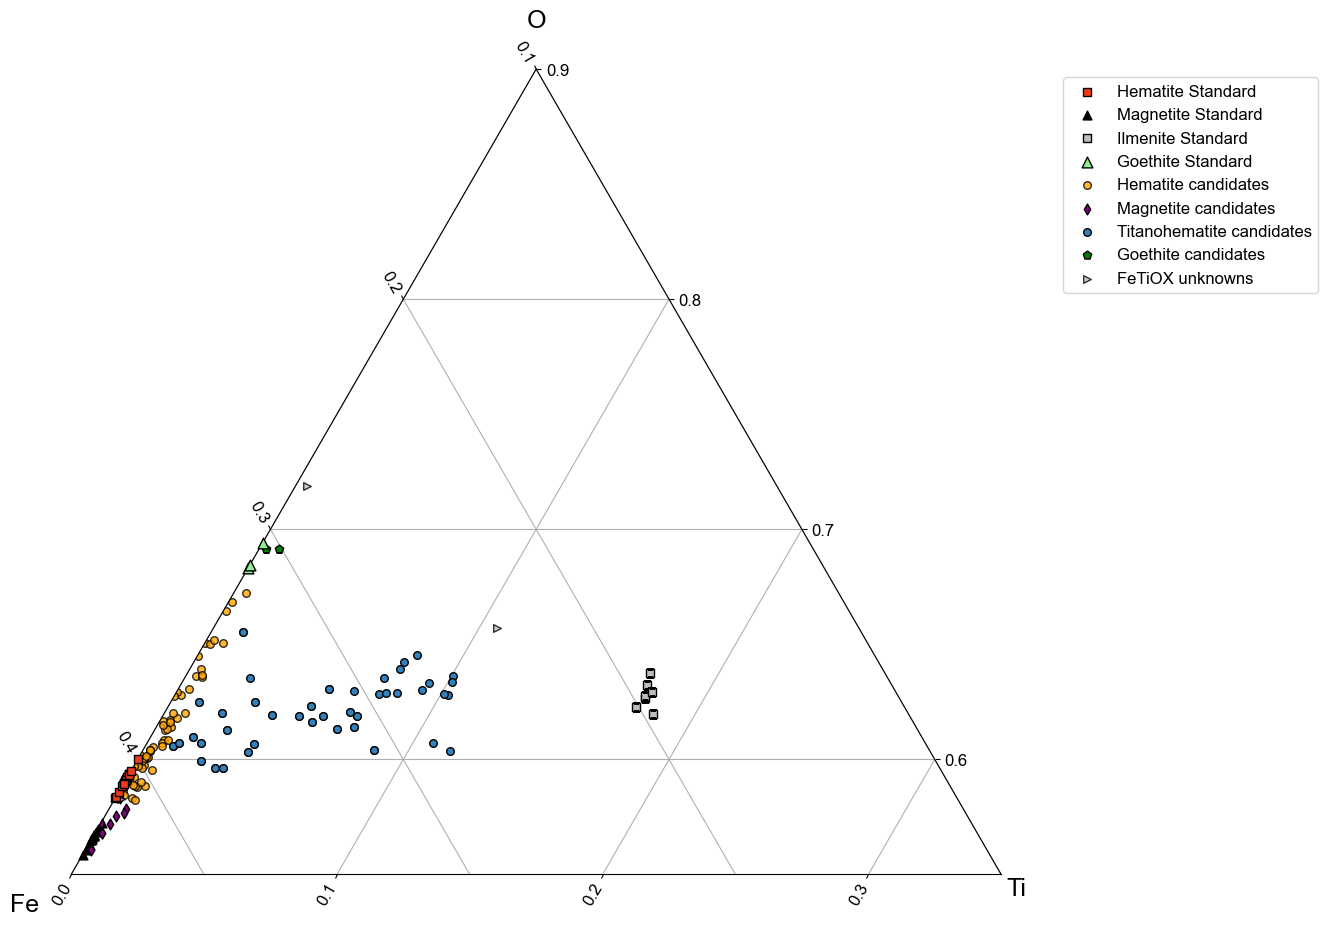

In [23]:
fig = plt.figure(figsize=(12, 12))
fig.subplots_adjust(left=0.075, right=0.85, wspace=0.3)

ax = fig.add_subplot(1, 1, 1, projection="ternary")



fig=plot_feti_ternary(ax,hem_unk=dec_hem,mag_unk=dec_mag,ti_hem_unk=dec_titano_hem,gth_unk=dec_gt,misc_unk=dec_unk,
                  standards=dec_stds,std_styles=std_style_dict,unk_styles=unk_style_dict,zoom=True)

## January Data

In [24]:
jan13_fp='../data/eds/point_data/20250113_FeTiOx.csv'
jan14_fp='../data/eds/point_data/20250114_FeTiOx.csv'
jan29_fp='../data/eds/point_data/20250129_FeTiOx.csv' # Different calibration

jan13_tables=read_pts(jan13_fp)
jan14_tables=read_pts(jan14_fp)
jan29_tables=read_pts(jan29_fp)


jan13_mc=mc_pts(jan13_tables)
jan14_mc=mc_pts(jan14_tables)
jan29_mc=mc_pts(jan29_tables)


jan13_stats=pt_stats(jan13_mc)
jan14_stats=pt_stats(jan14_mc)
jan29_stats=pt_stats(jan29_mc)


In [25]:
jan_phase_rules = {
    'hematite': {
        'Fe': [0.3, 0.4],
        'Ti':[0, 0.01],
        'O':[0.57,0.8]
           # Strict low Ti
    },
    'titanohematite': {
        'Fe': [0.25, 0.39], # Same Fe range as Hem
        'Ti': [0.01, 0.1]    # But higher Ti
    },
    'magnetite': {
        'Fe': [0.41, 0.45],
        'O':[0.4,0.58]
    },
    'ilmenite': {
        'Fe': [0.15, 0.2], # Adjusted to a realistic range (FeTiO3 is ~0.2)
        'Ti': [0.15, 0.25]
    },
    'goethite':{
        'Fe':[0.25,0.3],
        'O':[0.66,0.7]
    }
}

In [26]:
jan_stat=pd.concat([jan13_stats,jan14_stats,jan29_stats])
jan_unk, jan_stds=split_standards(jan_stat,std_definitions)

/var/folders/cj/xt_j0gq17bz7v5r3hl3h6fxm0000gn/T/ipykernel_2673/2967362206.py:19: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  is_unknown = df['Grain'].str.contains(unknown_regex, regex=True, na=False)


In [27]:
jan_grains= classify_phases(jan_unk,jan_phase_rules)

jan_hem= jan_grains['hematite']
jan_titano_hem = jan_grains['titanohematite']
jan_mag=jan_grains['magnetite']
jan_gt=jan_grains['goethite']
jan_unk = jan_grains['misc']

print(f"Found {len(jan_hem)} Hematite grains.")
print(f"Found {len(jan_titano_hem)} Titano-Hematite grains.")
print(f"Found {len(jan_mag)} magnetite grains.")
print(f"Found {len(jan_gt)} Goethite grains.")
print(f"Found {len(jan_unk)} Unclassified grains.")

Found 217 Hematite grains.
Found 46 Titano-Hematite grains.
Found 6 magnetite grains.
Found 4 Goethite grains.
Found 6 Unclassified grains.


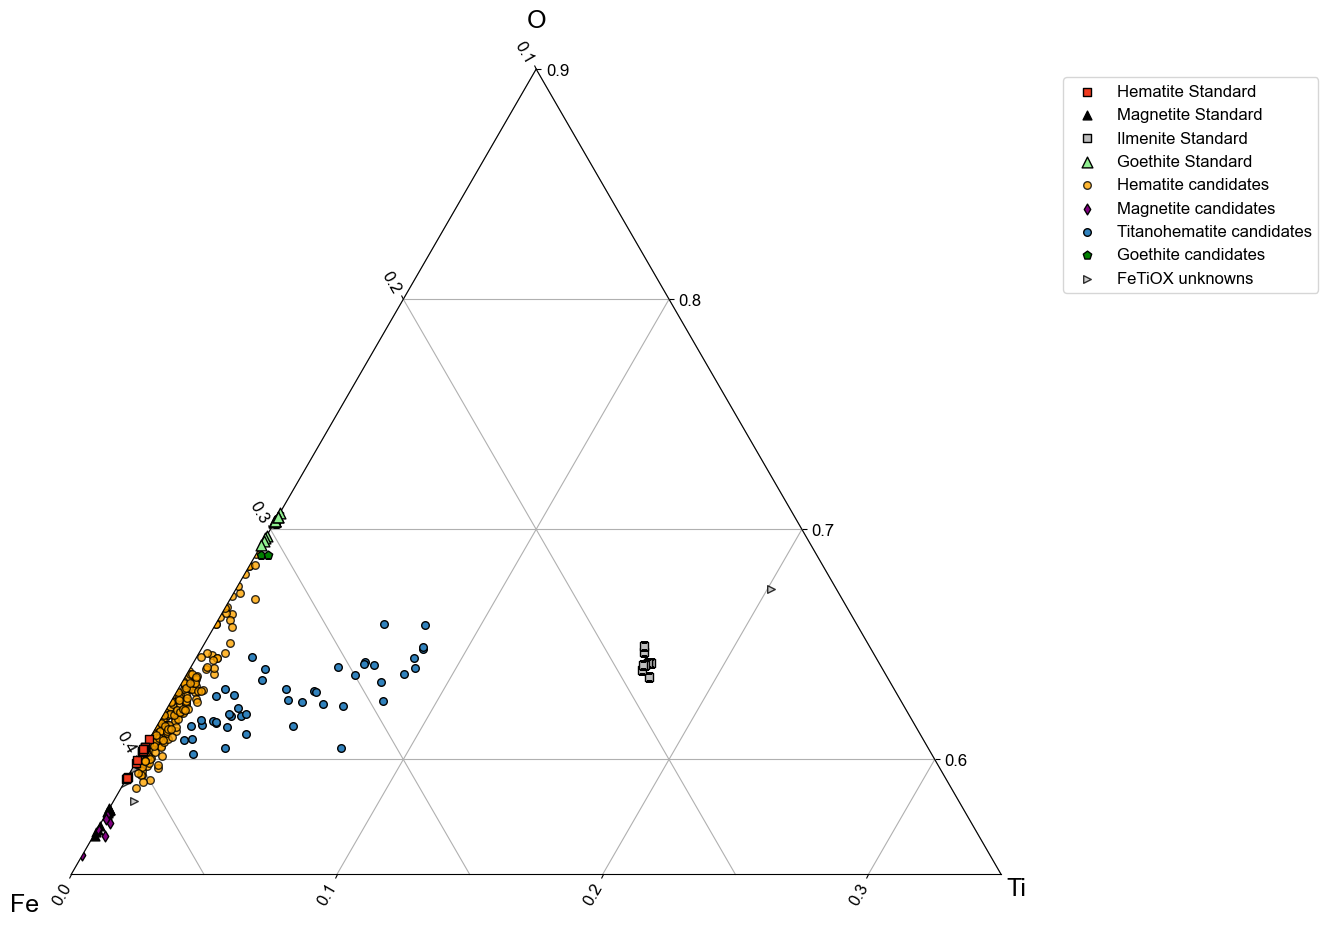

In [28]:
fig = plt.figure(figsize=(12, 12))
fig.subplots_adjust(left=0.075, right=0.85, wspace=0.3)

ax = fig.add_subplot(1, 1, 1, projection="ternary")




fig=plot_feti_ternary(ax,hem_unk=jan_hem,mag_unk=jan_mag,ti_hem_unk=jan_titano_hem,gth_unk=jan_gt,misc_unk=jan_unk,
                  standards=jan_stds,std_styles=std_style_dict,unk_styles=unk_style_dict,zoom=True)

## September Data

In [34]:
sep_fp='../data/eds/point_data/20250930_FeTiOx.csv'

sep_tables=read_pts(sep_fp)

sep=mc_pts(sep_tables)
sep=pt_stats(sep)

In [35]:
sept_phase_rules = {
    'hematite': {
        'Fe': [0.30, 0.41],
          'O':[0.57,0.66]  # Strict low Ti
    },
    'titanohematite': {
        'Fe': [0.25, 0.39], # Same Fe range as Hem
        'Ti': [0.01, 0.15]    # But higher Ti
    },
    'magnetite': {
        'Fe': [0.41, 0.45],
        'O':[0.4,0.585]
    },
    'ilmenite': {
        'Fe': [0.15, 0.25], # Adjusted to a realistic range (FeTiO3 is ~0.2)
        'Ti': [0.15, 0.25]
    },
    'goethite':{
        'Fe':[0.25,0.3],
        'O':[0.66,0.7]
    }
}

In [36]:


sept_unk, sep_stds_dict = split_standards(sep, std_definitions)

/var/folders/cj/xt_j0gq17bz7v5r3hl3h6fxm0000gn/T/ipykernel_2673/2967362206.py:19: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  is_unknown = df['Grain'].str.contains(unknown_regex, regex=True, na=False)


In [37]:
sept_grains = classify_phases(sept_unk,sept_phase_rules)

In [38]:


sept_hem= sept_grains['hematite']
sept_titano_hem = sept_grains['titanohematite']
sept_mag=sept_grains['magnetite']
sept_gt=sept_grains['goethite']
sept_unk = sept_grains['misc']

print(f"Found {len(sept_hem)} Hematite grains.")
print(f"Found {len(sept_titano_hem)} Titano-Hematite grains.")
print(f"Found {len(sept_mag)} magnetite grains.")
print(f"Found {len(sept_gt)} Goethite grains.")
print(f"Found {len(sept_unk)} Unclassified grains.")

Found 32 Hematite grains.
Found 12 Titano-Hematite grains.
Found 0 magnetite grains.
Found 2 Goethite grains.
Found 14 Unclassified grains.


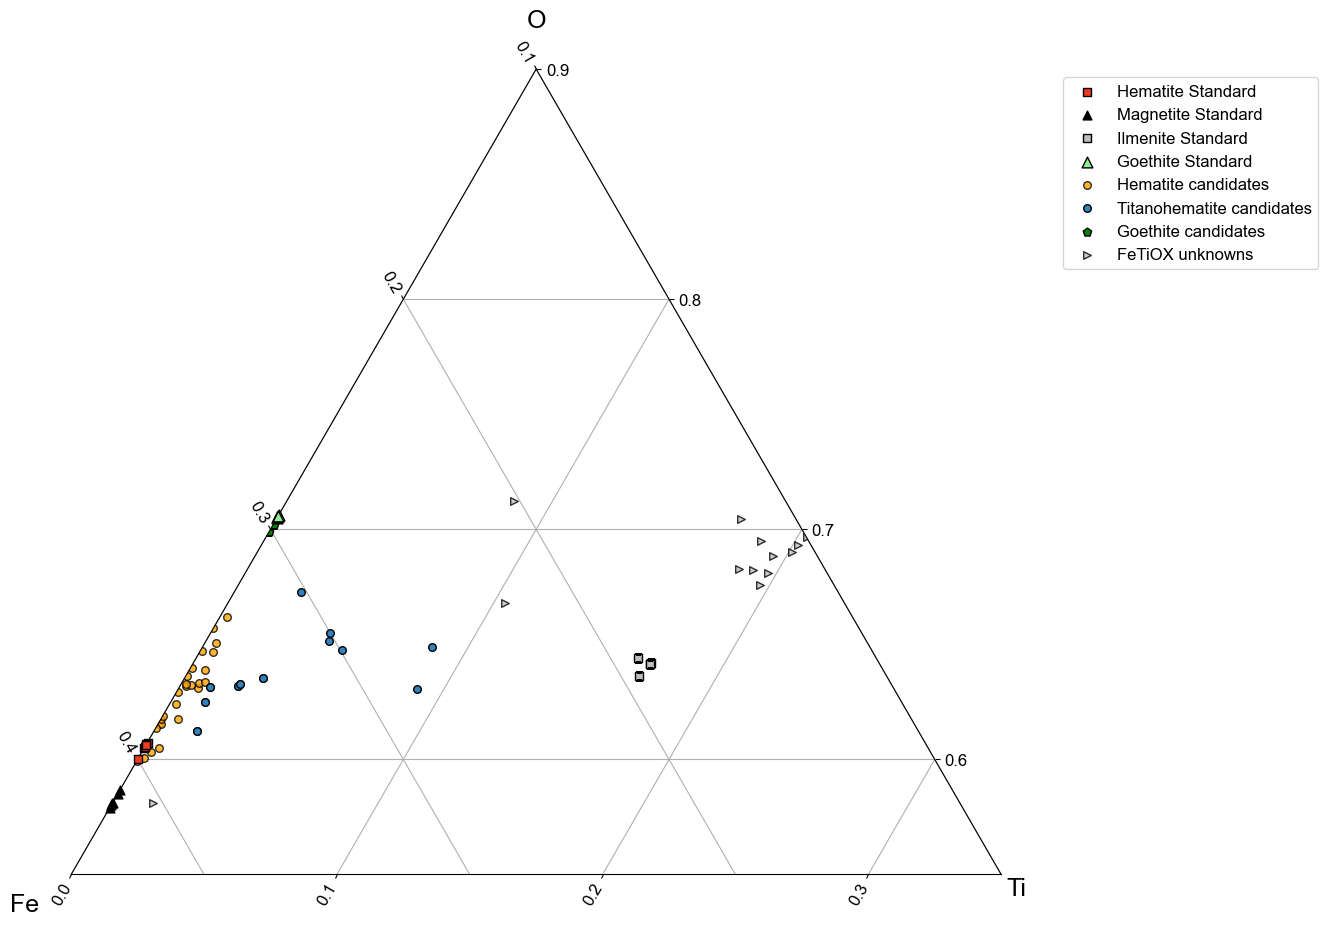

In [39]:
fig = plt.figure(figsize=(12, 12))
fig.subplots_adjust(left=0.075, right=0.85, wspace=0.3)

ax = fig.add_subplot(1, 1, 1, projection="ternary")



fig=plot_feti_ternary(ax,hem_unk=sept_hem,mag_unk=sept_mag,ti_hem_unk=sept_titano_hem,gth_unk=sept_gt,misc_unk=sept_unk,
                  standards=sep_stds_dict,std_styles=std_style_dict,unk_styles=unk_style_dict,zoom=True)

## Dual Ternary 

In [40]:
jan_data={'hematite':jan_hem,'magnetite':jan_mag,'goethite':jan_gt,'titanohematite':jan_titano_hem,'misc':jan_unk}
dec_data={'titanohematite':dec_titano_hem,'hematite':dec_hem,'magnetite':dec_mag,'goethite':dec_gt,'misc':dec_unk,}

In [41]:
leg_format={'frameon':True,'fancybox':False,'framealpha':1,'edgecolor':'black'}

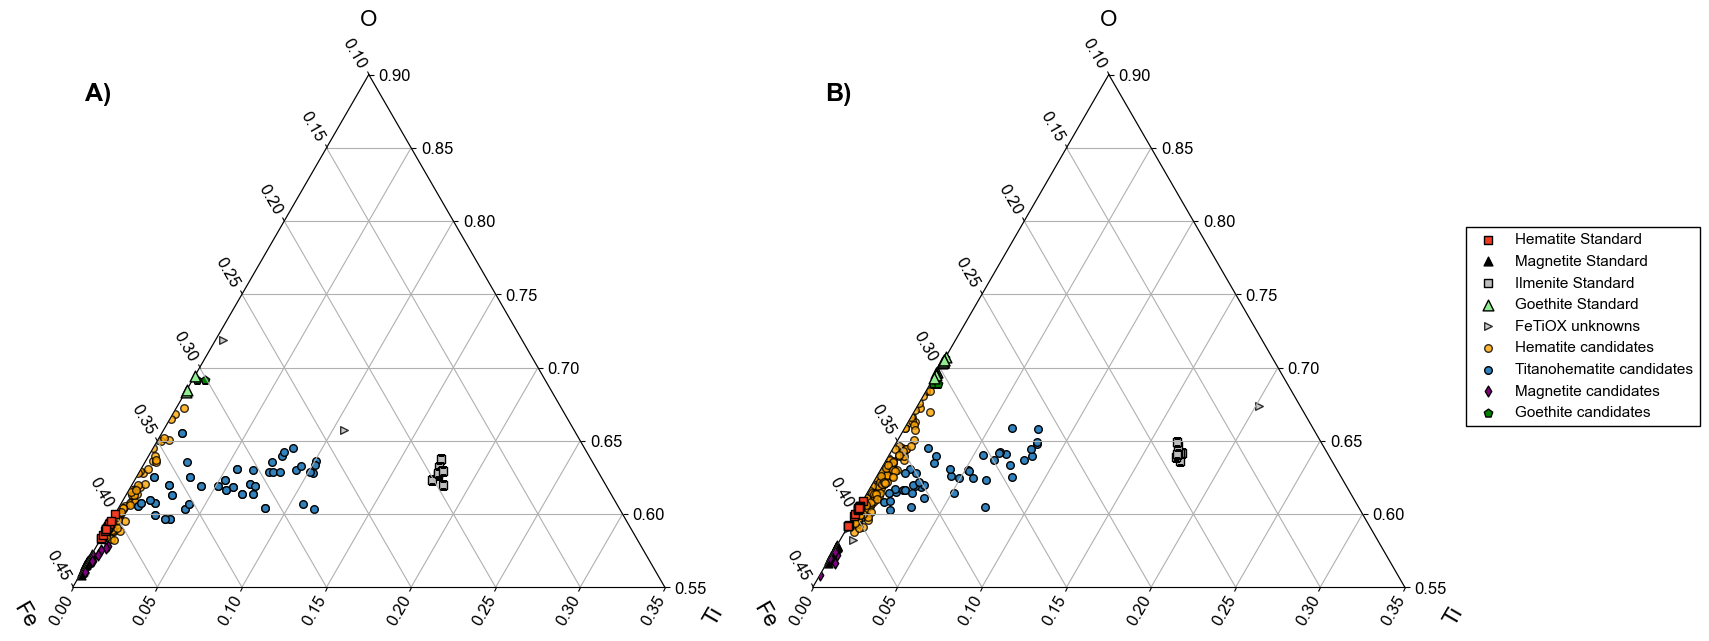

In [46]:
fig=plot_dual_ternary(dec_data,dec_stds,jan_data,jan_stds,std_styles=std_style_dict,unk_styles=unk_style_dict,legend_kwargs=leg_format)
fig.savefig('../figures/si_fig/combined_ternary.pdf',dpi=300,bbox_inches='tight')

## Export Labeled Data 

- Round up grain labels for export to be used in the R script for single grains 
- Export compositional Data 

In [48]:
all_hematite= pd.concat([dec_hem,jan_hem,sept_hem],ignore_index=True)
all_titanohematite=pd.concat([dec_titano_hem,jan_titano_hem,sept_titano_hem],ignore_index=True)


all_hematite['Grain'].to_csv('../data/eds/class/total_hematite_v2.csv',index=False)
all_titanohematite['Grain'].to_csv('../data/eds/class/total_titano_hematite_v2.csv',index=False)

In [79]:
all_hematite.to_csv('../data/eds/atomic_tables/all_hematite.csv',index=False)
all_titanohematite.to_csv('../data/eds/atomic_tables/all_titano.csv',index=False)

Save Reduced Data

In [55]:
map_stat.to_csv('../data/eds/atomic_tables/map.csv',index=False)
dec12_stat.to_csv('../data/eds/atomic_tables/dec_12.csv',index=False)
dec18_stat.to_csv('../data/eds/atomic_tables/dec_18.csv',index=False)
dec19_stat.to_csv('../data/eds/atomic_tables/dec_19.csv',index=False)


jan13_stats.to_csv('../data/eds/atomic_tables/jan_13.csv',index=False)
jan14_stats.to_csv('../data/eds/atomic_tables/jan_14.csv',index=False)
jan29_stats.to_csv('../data/eds/atomic_tables/jan_29.csv',index=False)

sep.to_csv('../data/eds/atomic_tables/sep_30.csv',index=False)


In [73]:
atomic_tables=pd.concat([sep,jan29_stats,jan14_stats,jan13_stats,dec19_stat,dec18_stat,dec12_stat,map_stat],axis=0,ignore_index=True)

In [76]:
atomic_tables.sort_values(by='Grain',inplace=True)
atomic_tables.to_csv('../data/eds/atomic_tables/full_eds_table.csv',index=False)

## Textural Grouping and Compositional Piecharts

In [50]:
texture_colors = {
    'M':  '#2c7bb6',  #
    'MH': '#abd9e9',  
    'EH': '#d7191c',  
    'IF': '#fdae61',  
    'FH': '#ffffbf',  
    'Unknown': 'gray'
}

text_labels = {
    'M': 'Massive Hematite',
    'MH': 'Micaceous Hematite', 
    'EH': 'Exsolved Hematite', 
    'IF': 'Iron Formation', 
    'FH': 'Fibrous Hematite'
}

font_dict={'family': 'arial',
           'fontsize':12}

pie_leg={'frameon':True,'fancybox':False,'framealpha':1,'edgecolor':'black','font':'arial'}

In [51]:
brc01_txt=pd.read_csv('../data/geochron/plotting/grain_textures/brc_textures.csv')
brc02_txt=pd.read_csv('../data/geochron/plotting/grain_textures/brc02_textures.csv')
lra01_txt=pd.read_csv('../data/geochron/plotting/grain_textures/lra01_textures.csv')
lra02_txt=pd.read_csv('../data/geochron/plotting/grain_textures/lra02_textures.csv')
bre_text=pd.read_csv('../data/geochron/plotting/grain_textures/bre_textures.csv')

lra_text=pd.concat([lra01_txt,lra02_txt],ignore_index=True)
brc_text=pd.concat([brc01_txt,brc02_txt],ignore_index=True)

In [52]:
text_dict={'LRa':lra_text,'BRe':bre_text,'BRc':brc_text}

In [53]:
lra_hem=all_hematite[all_hematite['Grain'].str.contains('LRa')]
lra_titano=all_titanohematite[all_titanohematite['Grain'].str.contains('LRa')]

bre_hem=all_hematite[all_hematite['Grain'].str.contains('BRe')]
bre_titano=all_titanohematite[all_titanohematite['Grain'].str.contains('BRe')]


brc_hem=all_hematite[all_hematite['Grain'].str.contains('BRc')]
brc_titano=all_titanohematite[all_titanohematite['Grain'].str.contains('BRc')]

comp_dict={'LRa_hematite':lra_hem,'LRa_titano':lra_titano,
           'BRe_hematite':bre_hem,'BRe_titano':bre_titano,
           'BRc_hematite':brc_hem,'BRc_titano':brc_titano}

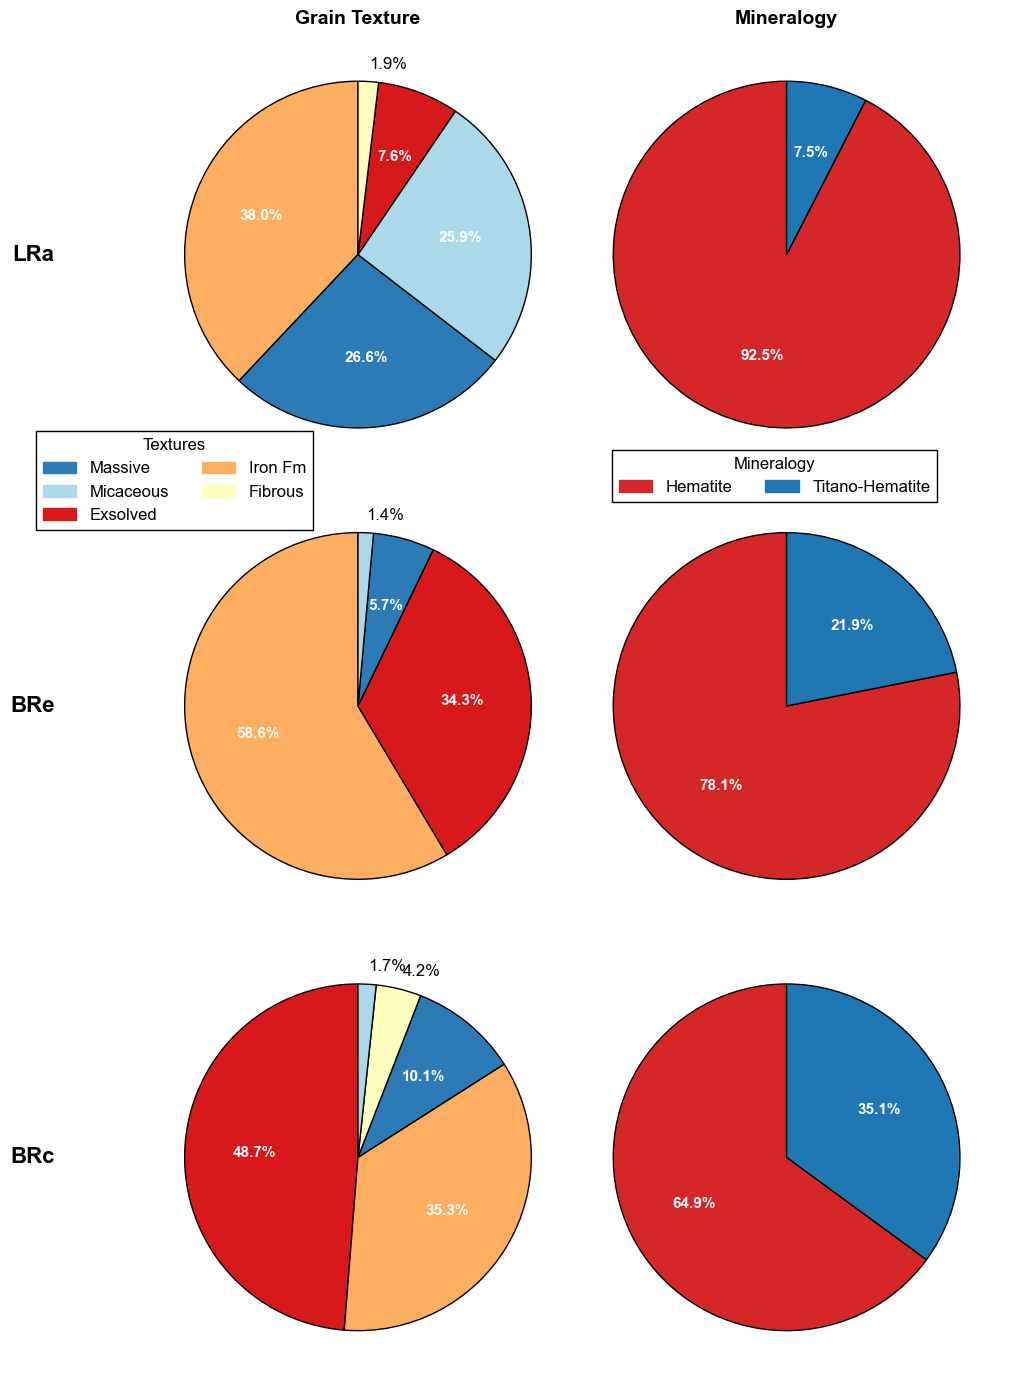

In [54]:
fig = plot_dual_strat_grid(
    texture_data=text_dict,    # Your new dictionary
    comp_data=comp_dict,       # The composition dictionary
    strat_order=['LRa', 'BRe', 'BRc'],
    tex_colors=texture_colors,
    show_n=False,
    text_kwargs=font_dict,
    figsize=(10, 14),
    tex_legend_ncol=2,
    tex_legend_bbox=(0.15,0.61),
    comp_legend_bbox=(0.75,0.63),
    legend_kwargs=leg_format # Pass formatting here
)

fig.tight_layout()

fig.savefig('../figures/si_fig/pie_charts.pdf',bbox_inches='tight')

## EDS Standards KDEs

In [33]:
hem_370=pd.concat(dec18_mc[:9],ignore_index=True)
mag_ref=pd.concat(dec18_mc[10:18],ignore_index=True)
mag_puck=pd.concat(dec18_mc[23:26],ignore_index=True)
hem_elba_ref=pd.concat(dec18_mc[19:22],ignore_index=True)
jk25=pd.concat(dec19_mc[37:40],ignore_index=True)

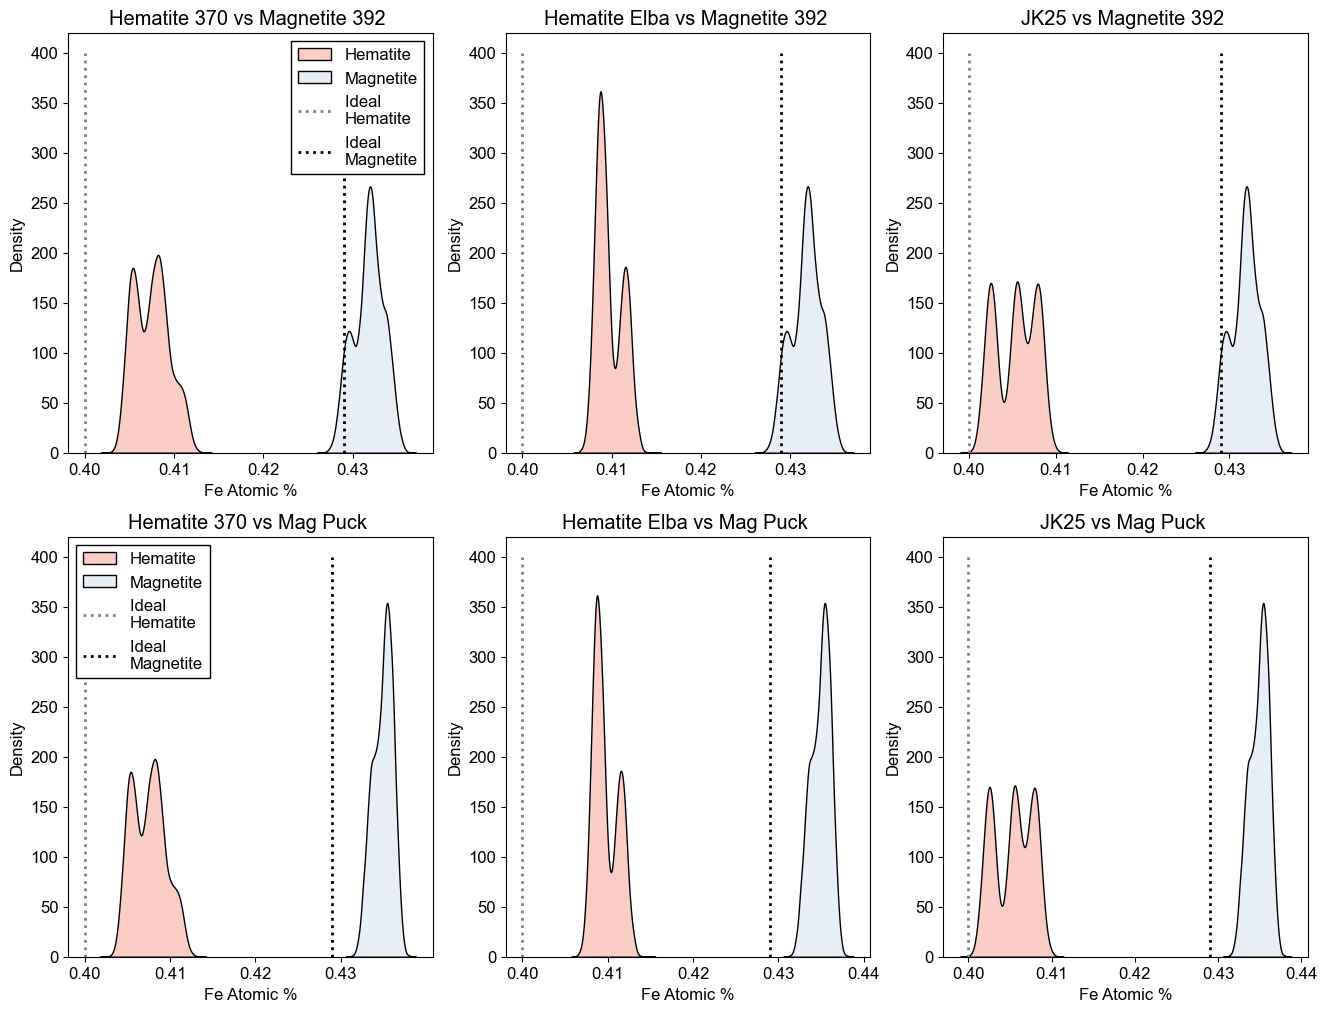

In [36]:
fig, ax = plt.subplots(2, 3, figsize=(16, 12))
                         

sns.kdeplot(hem_370['Fe'],ax=ax[0, 0],fill=True,color='#f03b20',edgecolor='black',label='Hematite')
sns.kdeplot(mag_ref['Fe'],ax=ax[0, 0],fill=True,color='#a6bddb',edgecolor='black',label='Magnetite')
ax[0, 0].set_title('Hematite 370 vs Magnetite 392 ')

ax[0, 0].vlines(x=0.4, ymin=0,ymax=400,linestyles='dotted',color='grey',linewidth=2,label='Ideal \nHematite')
ax[0, 0].vlines(x=0.429, ymin=0,ymax=400,linestyles='dotted',color='black',linewidth=2,label='Ideal \nMagnetite')
ax[0,0].legend(fancybox=False,framealpha=1,edgecolor='black')
ax[0,0].set_xlabel('Fe Atomic %')
ax[0,0].set_xticks(np.arange(0.4,0.44,0.01))



sns.kdeplot(hem_elba_ref['Fe'],ax=ax[0, 1],fill=True,color='#f03b20',edgecolor='black',label='Hematite')
sns.kdeplot(mag_ref['Fe'],ax=ax[0, 1],fill=True,color='#a6bddb',edgecolor='black',label='Magnetite')
ax[0, 1].set_title('Hematite Elba vs Magnetite 392 ')

ax[0, 1].vlines(x=0.4, ymin=0,ymax=400,linestyles='dotted',color='grey',linewidth=2,label='Ideal \nHematite')
ax[0, 1].vlines(x=0.429, ymin=0,ymax=400,linestyles='dotted',color='black',linewidth=2,label='Ideal \nMagnetite')
ax[0,1].set_xlabel('Fe Atomic %')
#ax[0,1].xticks(np.arange(0.4,0.44,0.01))

sns.kdeplot(jk25['Fe'],ax=ax[0, 2],fill=True,color='#f03b20',edgecolor='black',label='Hematite')
sns.kdeplot(mag_ref['Fe'],ax=ax[0, 2],fill=True,color='#a6bddb',edgecolor='black',label='Magnetite')
ax[0, 2].set_title('JK25 vs Magnetite 392 ')

ax[0, 2].vlines(x=0.4, ymin=0,ymax=400,linestyles='dotted',color='grey',linewidth=2,label='Ideal \nHematite')
ax[0, 2].vlines(x=0.429, ymin=0,ymax=400,linestyles='dotted',color='black',linewidth=2,label='Ideal \nMagnetite')
ax[0,2].set_xlabel('Fe Atomic %')
#ax[0,1].xticks(np.arange(0.4,0.44,0.01))



sns.kdeplot(hem_370['Fe'],ax=ax[1, 0],fill=True,color='#f03b20',edgecolor='black',label='Hematite')
sns.kdeplot(mag_puck['Fe'],ax=ax[1, 0],fill=True,color='#a6bddb',edgecolor='black',label='Magnetite')
ax[1, 0].set_title('Hematite 370 vs Mag Puck ')

ax[1, 0].vlines(x=0.4, ymin=0,ymax=400,linestyles='dotted',color='grey',linewidth=2,label='Ideal \nHematite')
ax[1, 0].vlines(x=0.429, ymin=0,ymax=400,linestyles='dotted',color='black',linewidth=2,label='Ideal \nMagnetite')
ax[1,0].legend(fancybox=False,framealpha=1,edgecolor='black')
ax[1,0].set_xlabel('Fe Atomic %')
ax[1,0].set_xticks(np.arange(0.4,0.44,0.01))


sns.kdeplot(hem_elba_ref['Fe'],ax=ax[1, 1],fill=True,color='#f03b20',edgecolor='black',label='Hematite')
sns.kdeplot(mag_puck['Fe'],ax=ax[1, 1],fill=True,color='#a6bddb',edgecolor='black',label='Magnetite')
ax[1, 1].set_title('Hematite Elba vs Mag Puck ')

ax[1, 1].vlines(x=0.4, ymin=0,ymax=400,linestyles='dotted',color='grey',linewidth=2,label='Ideal \nHematite')
ax[1, 1].vlines(x=0.429, ymin=0,ymax=400,linestyles='dotted',color='black',linewidth=2,label='Ideal \nMagnetite')
ax[1,1].set_xlabel('Fe Atomic %')
#ax[0,1].xticks(np.arange(0.4,0.44,0.01))


sns.kdeplot(jk25['Fe'],ax=ax[1, 2],fill=True,color='#f03b20',edgecolor='black',label='Hematite')
sns.kdeplot(mag_puck['Fe'],ax=ax[1, 2],fill=True,color='#a6bddb',edgecolor='black',label='Magnetite')
ax[1, 2].set_title('JK25 vs Mag Puck ')

ax[1, 2].vlines(x=0.4, ymin=0,ymax=400,linestyles='dotted',color='grey',linewidth=2,label='Ideal \nHematite')
ax[1, 2].vlines(x=0.429, ymin=0,ymax=400,linestyles='dotted',color='black',linewidth=2,label='Ideal \nMagnetite')
ax[1,2].set_xlabel('Fe Atomic %')
#ax[0,1].xticks(np.arange(0.4,0.44,0.01))



plt.savefig('../figures/si_fig/multispot_kde.pdf',dpi=300,bbox_inches='tight')
